# 🧠 Build Your Own Tiny LLM From Scratch
### A hands-on class notebook — from raw text to a working (and fine-tuned) mini GPT

In this notebook we build a **real GPT-style Large Language Model** — the same architecture family as ChatGPT, Claude and Llama — just **tiny** (~0.8 million parameters instead of billions), so it trains in a few minutes on a free Google Colab GPU.

| # | Part | What students learn | ⏱ Suggested time |
|---|------|--------------------|------------------|
| 0 | Setup | Libraries, GPU | 5 min |
| 1 | **Input data processing** | Dataset → tokens → numbers → training batches | 20 min |
| 2 | **The LLM architecture** | Embeddings, self-attention, Transformer blocks | 30 min |
| 3 | **Training** | Next-token prediction, loss, backpropagation | 20 min |
| 4 | **Using the model** | Generating text, temperature, top-k | 10 min |
| 5 | **Fine-tuning** | Full fine-tuning + LoRA (how it's done in industry) | 25 min |
| 6 | Bonus | Using & fine-tuning a *real* small pretrained LLM | 10 min |

> **Before class:** `Runtime → Change runtime type → T4 GPU`, then `Runtime → Run all` once to check everything works. The notebook also runs on CPU (just slower — training automatically uses fewer steps).

**The one big idea to remember:**
> An LLM is a machine that, given some text, **predicts the next token**. Everything else — chatting, answering, coding — comes from doing that one thing over and over.

---
## Part 0 — Setup
We only need **PyTorch** (already installed on Colab). No special LLM libraries — we write everything ourselves.

In [1]:
import math, time, urllib.request
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(42)  # makes results reproducible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("PyTorch version:", torch.__version__)
print("Running on     :", device.upper(), "🚀" if device == 'cuda' else "(tip: switch to a T4 GPU runtime for speed)")

PyTorch version: 2.11.0+cpu
Running on     : CPU (tip: switch to a T4 GPU runtime for speed)


---
## Part 1 — How input data is processed

An LLM never sees "text". It only sees **numbers**. The pipeline is:

```
Raw text  ──►  Tokens  ──►  Token IDs (integers)  ──►  Training examples (input → target)
"Hello"       H,e,l,l,o       20, 43, 50, 50, 53        [20,43,50,50] → [43,50,50,53]
```

### 1.1 Get a dataset
We use **Tiny Shakespeare**: ~1 MB of Shakespeare plays (public domain). Real LLMs train on *trillions* of tokens from the internet, books and code — but the process is identical.

In [2]:
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
try:
    text = urllib.request.urlopen(url, timeout=30).read().decode("utf-8")
except Exception as e:
    # Fallback so the class never gets stuck if the internet is slow
    print("Download failed, using a small built-in text instead:", e)
    text = ("First Citizen:\nBefore we proceed any further, hear me speak.\n\n"
            "All:\nSpeak, speak.\n\nFirst Citizen:\nYou are all resolved rather to die than to famish?\n\n"
            "All:\nResolved. resolved.\n\n") * 300

print(f"Dataset size: {len(text):,} characters")
print("=" * 50)
print(text[:500])

Dataset size: 1,115,394 characters
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


### 1.2 Tokenization — splitting text into pieces
A **token** is the basic unit the model reads and writes. There are different strategies:

| Strategy | Example for `"unbelievable"` | Vocabulary size | Used by |
|---|---|---|---|
| Character-level | `u n b e l i e v a b l e` (12 tokens) | ~65 | our tiny model ✅ |
| Sub-word (BPE) | `un believ able` (3 tokens) | 50k – 200k | GPT, Claude, Llama |
| Word-level | `unbelievable` (1 token) | millions | old NLP models |

We use **characters** because it's the simplest to understand. Real LLMs use sub-words (BPE), which we peek at below.

In [3]:
# Build the vocabulary: every unique character in the dataset
chars = sorted(set(text))
vocab_size = len(chars)
print(f"Vocabulary size: {vocab_size}")
print("Vocabulary:", repr(''.join(chars)))

Vocabulary size: 65
Vocabulary: "\n !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"


In [4]:
# Two lookup tables: character -> integer, and integer -> character
stoi = {ch: i for i, ch in enumerate(chars)}   # "string to integer"
itos = {i: ch for i, ch in enumerate(chars)}   # "integer to string"

def encode(s):  return [stoi[c] for c in s]           # text  -> list of IDs
def decode(ids): return ''.join(itos[i] for i in ids)  # IDs   -> text

example = "Hello class!"
ids = encode(example)
print("Text     :", example)
print("Token IDs:", ids)
print("Decoded  :", decode(ids))
print()
for ch, i in zip(example, ids):
    print(f"  '{ch}' -> {i}")

Text     : Hello class!
Token IDs: [20, 43, 50, 50, 53, 1, 41, 50, 39, 57, 57, 2]
Decoded  : Hello class!

  'H' -> 20
  'e' -> 43
  'l' -> 50
  'l' -> 50
  'o' -> 53
  ' ' -> 1
  'c' -> 41
  'l' -> 50
  'a' -> 39
  's' -> 57
  's' -> 57
  '!' -> 2


#### 👀 Peek: how a *real* LLM tokenizes (GPT-2's BPE tokenizer)
Optional — needs the `tiktoken` library. Notice whole words or word-pieces become single tokens.

In [5]:
try:
    import tiktoken
except ImportError:
    !pip -q install tiktoken
    import tiktoken

enc = tiktoken.get_encoding("gpt2")
sentence = "Tokenization is unbelievably important for LLMs!"
toks = enc.encode(sentence)
print(f"{len(sentence)} characters  ->  {len(toks)} BPE tokens (vocab size {enc.n_vocab:,})")
print([enc.decode([t]) for t in toks])
print(toks)

48 characters  ->  9 BPE tokens (vocab size 50,257)
['Token', 'ization', ' is', ' unbelievably', ' important', ' for', ' LL', 'Ms', '!']
[30642, 1634, 318, 48943, 1593, 329, 27140, 10128, 0]


### 1.3 Turn the whole dataset into one long tensor of numbers
and split it: **90% for training**, **10% for validation** (text the model never trains on — used to check it is really *learning* and not just memorising).

In [6]:
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]

print("Total tokens     :", f"{len(data):,}")
print("Training tokens  :", f"{len(train_data):,}")
print("Validation tokens:", f"{len(val_data):,}")
print("First 30 IDs     :", data[:30].tolist())

Total tokens     : 1,115,394
Training tokens  : 1,003,854
Validation tokens: 111,540
First 30 IDs     : [18, 47, 56, 57, 58, 1, 15, 47, 58, 47, 64, 43, 52, 10, 0, 14, 43, 44, 53, 56, 43, 1, 61, 43, 1, 54, 56, 53, 41, 43]


### 1.4 Create training examples: *input → next token*
This is **the key idea of LLM training**. From one chunk of text we get *many* training examples for free — no human labelling needed! (This is why it's called **self-supervised** learning.)

For a chunk of `block_size` tokens, the model learns to predict each next token from everything before it:

In [7]:
block_size = 8   # just for this demo
x = train_data[:block_size]
y = train_data[1:block_size + 1]   # the targets are the inputs shifted by ONE position

print("Input  x:", repr(decode(x.tolist())))
print("Target y:", repr(decode(y.tolist())))
print()
for t in range(block_size):
    context, target = x[:t + 1], y[t]
    print(f"when input is {repr(decode(context.tolist())):<14} -> the model should predict {repr(decode([target.item()]))}")

Input  x: 'First Ci'
Target y: 'irst Cit'

when input is 'F'            -> the model should predict 'i'
when input is 'Fi'           -> the model should predict 'r'
when input is 'Fir'          -> the model should predict 's'
when input is 'Firs'         -> the model should predict 't'
when input is 'First'        -> the model should predict ' '
when input is 'First '       -> the model should predict 'C'
when input is 'First C'      -> the model should predict 'i'
when input is 'First Ci'     -> the model should predict 't'


### 1.5 Batches
GPUs are fast because they process many examples **in parallel**. We grab `batch_size` random chunks at once.

In [8]:
def get_batch(split, batch_size, block_size):
    d = train_data if split == 'train' else val_data
    ix = torch.randint(len(d) - block_size, (batch_size,))        # random starting positions
    x = torch.stack([d[i:i + block_size] for i in ix])            # inputs
    y = torch.stack([d[i + 1:i + block_size + 1] for i in ix])    # targets (shifted by 1)
    return x.to(device), y.to(device)

xb, yb = get_batch('train', batch_size=4, block_size=8)
print("Input batch shape:", tuple(xb.shape), " (batch_size, block_size)")
print(xb)
print("Target batch:")
print(yb)

Input batch shape: (4, 8)  (batch_size, block_size)
tensor([[57,  1, 46, 47, 57,  1, 50, 53],
        [ 1, 58, 46, 43, 56, 43,  1, 41],
        [17, 26, 15, 17, 10,  0, 32, 53],
        [57, 58,  6,  1, 61, 47, 58, 46]])
Target batch:
tensor([[ 1, 46, 47, 57,  1, 50, 53, 60],
        [58, 46, 43, 56, 43,  1, 41, 39],
        [26, 15, 17, 10,  0, 32, 53,  1],
        [58,  6,  1, 61, 47, 58, 46,  0]])


✅ **Part 1 summary:** text → characters → integer IDs → random (input, shifted-target) chunks. That's all the data processing an LLM needs.

---
## Part 2 — The LLM architecture (the Transformer / GPT)

```
 Token IDs  [18, 47, 56, 57]
     │
     ▼
 ┌─────────────────────────────┐
 │ Token Embedding             │  each ID  -> a vector of numbers (its "meaning")
 │      +                      │
 │ Position Embedding          │  each position -> a vector ("where am I in the sentence")
 └─────────────────────────────┘
     │
     ▼
 ┌─────────────────────────────┐ ┐
 │ LayerNorm                   │ │
 │ Masked Multi-Head Attention │ │  tokens LOOK AT previous tokens and gather information
 │   + residual connection     │ │
 │ LayerNorm                   │ │  × N layers  (Transformer Blocks)
 │ Feed-Forward network (MLP)  │ │  each token "THINKS" about what it gathered
 │   + residual connection     │ │
 └─────────────────────────────┘ ┘
     │
     ▼
 ┌─────────────────────────────┐
 │ Final LayerNorm + Linear    │  vector -> one score ("logit") per vocabulary token
 └─────────────────────────────┘
     │
     ▼
 Softmax -> probabilities of the NEXT token   e.g.  'e': 61%,  'a': 12%, ...
```

We'll build each piece one by one.

### 2.1 Embeddings: turning IDs into vectors
An ID like `47` has no meaning by itself. An **embedding table** gives each token a learnable vector. During training, tokens used in similar ways end up with similar vectors.

In [9]:
n_embd_demo = 8
token_embedding = nn.Embedding(vocab_size, n_embd_demo)   # a table: vocab_size rows × 8 columns

ids = torch.tensor(encode("Hi"))
vectors = token_embedding(ids)
print("IDs:", ids.tolist())
print("Each ID becomes a vector of", n_embd_demo, "numbers (random now, LEARNED during training):")
print(vectors.detach())

IDs: [20, 47]
Each ID becomes a vector of 8 numbers (random now, LEARNED during training):
tensor([[ 0.2868, -0.7308,  0.1748, -1.0939,  0.9633, -0.3095,  0.5712,  1.1179],
        [-0.5907,  0.8541, -0.4901, -0.3595, -0.0589, -0.4809,  0.9933,  0.2695]])


### 2.2 Self-attention — the heart of the Transformer 💡
Each token asks: **"Which earlier tokens are relevant to me?"**

Every token produces three vectors:
- **Query (Q)** — *"What am I looking for?"*
- **Key (K)** — *"What do I contain?"*
- **Value (V)** — *"What I'll share if you pay attention to me."*

Attention score between two tokens = `Q · K` (dot product: how well they match).
Then a **causal mask** hides the future (a token may not peek at the tokens it's supposed to predict!), **softmax** turns scores into weights that sum to 1, and each token takes the weighted average of the **Values**.

$$\text{Attention}(Q,K,V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}} + \text{mask}\right) V$$

Let's do it by hand on a tiny example:

Causal mask (1 = allowed to look):
 tensor([[1., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0.],
        [1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1.]])

Attention weights (row = token, col = which token it looks at):
[[1.   0.   0.   0.   0.  ]
 [0.49 0.51 0.   0.   0.  ]
 [0.27 0.33 0.4  0.   0.  ]
 [0.18 0.22 0.31 0.29 0.  ]
 [0.27 0.25 0.15 0.15 0.18]]

Output shape: (5, 4) -> each token now has a new vector containing info from its past


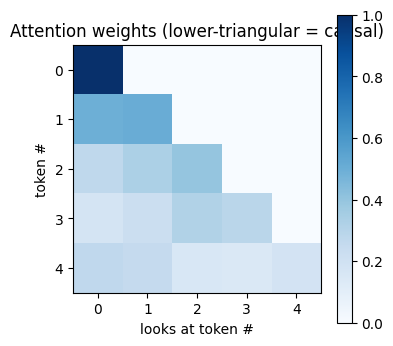

In [10]:
torch.manual_seed(0)
T, C, head_size = 5, 8, 4                 # 5 tokens, 8-dim embeddings, 4-dim attention head
x = torch.randn(T, C)                     # pretend these are 5 token embeddings

query = nn.Linear(C, head_size, bias=False)
key   = nn.Linear(C, head_size, bias=False)
value = nn.Linear(C, head_size, bias=False)
q, k, v = query(x), key(x), value(x)

# 1) raw scores: how much does each token match each other token?
scores = q @ k.T / math.sqrt(head_size)
# 2) causal mask: token i can only see tokens 0..i  (no peeking at the future!)
mask = torch.tril(torch.ones(T, T))
scores = scores.masked_fill(mask == 0, float('-inf'))
# 3) softmax -> each row sums to 1
weights = F.softmax(scores, dim=-1)
# 4) weighted average of the values
out = weights @ v

print("Causal mask (1 = allowed to look):\n", mask)
print("\nAttention weights (row = token, col = which token it looks at):")
print(weights.detach().numpy().round(2))
print("\nOutput shape:", tuple(out.shape), "-> each token now has a new vector containing info from its past")

plt.figure(figsize=(4, 4))
plt.imshow(weights.detach(), cmap='Blues')
plt.title("Attention weights (lower-triangular = causal)")
plt.xlabel("looks at token #"); plt.ylabel("token #"); plt.colorbar()
plt.show()

### 2.3 Building the real model in PyTorch
Now we package all of that into classes. Read them top to bottom — each one matches a box in the diagram above.

In [11]:
class Head(nn.Module):
    # ONE head of masked self-attention (exactly what we did by hand above)
    def __init__(self, n_embd, head_size, block_size, dropout):
        super().__init__()
        self.key   = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape                                          # batch, time (tokens), channels
        k, q, v = self.key(x), self.query(x), self.value(x)
        wei = q @ k.transpose(-2, -1) * k.shape[-1] ** -0.5        # (B, T, T) attention scores
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))  # hide the future
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        return wei @ v                                             # weighted sum of values


class MultiHeadAttention(nn.Module):
    # Several heads in parallel: each head can focus on a different kind of relationship
    def __init__(self, n_embd, n_head, block_size, dropout):
        super().__init__()
        head_size = n_embd // n_head
        self.heads = nn.ModuleList([Head(n_embd, head_size, block_size, dropout) for _ in range(n_head)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)        # concatenate all heads
        return self.dropout(self.proj(out))


class FeedForward(nn.Module):
    # A small neural network applied to each token separately: "thinking" after "looking"
    def __init__(self, n_embd, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )
    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    # One Transformer block = attention (communicate) + feed-forward (compute), with residuals
    def __init__(self, n_embd, n_head, block_size, dropout):
        super().__init__()
        self.ln1 = nn.LayerNorm(n_embd)
        self.attn = MultiHeadAttention(n_embd, n_head, block_size, dropout)
        self.ln2 = nn.LayerNorm(n_embd)
        self.ffwd = FeedForward(n_embd, dropout)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))   # residual connection: "add what you learned" to the input
        x = x + self.ffwd(self.ln2(x))
        return x


class TinyGPT(nn.Module):
    def __init__(self, vocab_size, n_embd, n_head, n_layer, block_size, dropout=0.1):
        super().__init__()
        self.block_size = block_size
        self.token_embedding = nn.Embedding(vocab_size, n_embd)      # WHAT the token is
        self.position_embedding = nn.Embedding(block_size, n_embd)   # WHERE the token is
        self.blocks = nn.Sequential(*[Block(n_embd, n_head, block_size, dropout) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)                 # vector -> score for each token

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok = self.token_embedding(idx)                                    # (B, T, n_embd)
        pos = self.position_embedding(torch.arange(T, device=idx.device))  # (T, n_embd)
        x = tok + pos
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)                                           # (B, T, vocab_size)

        loss = None
        if targets is not None:
            # Cross-entropy: how surprised was the model by the true next token?
            loss = F.cross_entropy(logits.view(B * T, -1), targets.view(B * T))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.block_size:]           # crop to the context window
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature        # only the LAST position predicts the next token
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('inf')
            probs = F.softmax(logits, dim=-1)              # scores -> probabilities
            idx_next = torch.multinomial(probs, num_samples=1)  # sample one token
            idx = torch.cat((idx, idx_next), dim=1)        # append it and repeat
        return idx

print("Model classes defined ✅")

Model classes defined ✅


### 2.4 Create our tiny model
These **hyperparameters** are the knobs that decide the model's size. Compare with real models:

| Setting | Our TinyGPT | GPT-2 small | GPT-3 |
|---|---|---|---|
| `n_embd` (vector size) | 128 | 768 | 12,288 |
| `n_head` (attention heads) | 4 | 12 | 96 |
| `n_layer` (blocks) | 4 | 12 | 96 |
| `block_size` (context window) | 128 | 1,024 | 2,048 |
| Parameters | **~0.8 M** | 124 M | 175,000 M |

In [12]:
config = dict(
    vocab_size = vocab_size,
    n_embd     = 128,
    n_head     = 4,
    n_layer    = 4,
    block_size = 128,
    dropout    = 0.1,
)
model = TinyGPT(**config).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"TinyGPT has {n_params:,} parameters ({n_params/1e6:.2f} M)")
print()
print(model)

TinyGPT has 824,897 parameters (0.82 M)

TinyGPT(
  (token_embedding): Embedding(65, 128)
  (position_embedding): Embedding(128, 128)
  (blocks): Sequential(
    (0): Block(
      (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attn): MultiHeadAttention(
        (heads): ModuleList(
          (0-3): 4 x Head(
            (key): Linear(in_features=128, out_features=32, bias=False)
            (query): Linear(in_features=128, out_features=32, bias=False)
            (value): Linear(in_features=128, out_features=32, bias=False)
            (dropout): Dropout(p=0.1, inplace=False)
          )
        )
        (proj): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (ffwd): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): GELU(approximate='none')
          (2): Line

### 2.5 Before training: the model knows nothing
Its weights are random, so its predictions are random. The expected starting loss is about `ln(vocab_size)` ≈ **4.17** (pure guessing among 65 characters).

In [13]:
xb, yb = get_batch('train', batch_size=4, block_size=config['block_size'])
logits, loss = model(xb, yb)
print("Logits shape:", tuple(logits.shape), "  (batch, tokens, one score per vocab entry)")
print(f"Loss before training: {loss.item():.3f}   (random guessing = ln({vocab_size}) = {math.log(vocab_size):.3f})")

start = torch.zeros((1, 1), dtype=torch.long, device=device)  # start from token 0 ('\n')
print("\nText generated by the UNTRAINED model:\n" + "-" * 50)
print(decode(model.generate(start, max_new_tokens=200)[0].tolist()))

Logits shape: (4, 128, 65)   (batch, tokens, one score per vocab entry)
Loss before training: 4.275   (random guessing = ln(65) = 4.174)

Text generated by the UNTRAINED model:
--------------------------------------------------

A
TAn-xQxXZcntdtD:HnUsZv
Mv,dOMDIH$WDzosquNcWIuocyNDrot-Ff;WTAeL:l;co:YiNRClnS3Xr$pCjHReJZbHJymS3WvS&PWzvn-?dJYScL&RtBQC;Pg,Zy?LnybtpWR?!iEGOBdVG!3rcAOyL3x$iP!C::kNb-GTaqXmntN'qbmtvcBYSK;!iHKJWn$
 .
'


---
## Part 3 — How the LLM is trained

Training is a loop repeated thousands of times:

```
 1. Take a random batch of text            (input tokens, target = next tokens)
 2. FORWARD pass  → model predicts probabilities for every next token
 3. LOSS          → cross-entropy: how wrong were the predictions?
 4. BACKWARD pass → backpropagation computes how each of the ~800k weights should change
 5. OPTIMIZER     → AdamW nudges every weight a tiny bit in the right direction
 6. Repeat!
```

Every single token position in every sequence is a training example — so one batch of 32 × 128 gives the model **4,096 predictions** to learn from per step.

In [14]:
@torch.no_grad()
def estimate_loss(model, batch_size, block_size, eval_iters=50):
    # Average the loss over several batches for a smooth, honest measurement
    model.eval()
    out = {}
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split, batch_size, block_size)
            _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

In [15]:
# ---- Training settings ----
batch_size    = 32
learning_rate = 1e-3
max_iters     = 3000 if device == 'cuda' else 600   # fewer steps on CPU so class doesn't wait
eval_interval = max_iters // 10

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
history = {'step': [], 'train': [], 'val': []}

t0 = time.time()
for step in range(max_iters + 1):
    # Every so often, measure progress
    if step % eval_interval == 0:
        losses = estimate_loss(model, batch_size, config['block_size'])
        history['step'].append(step); history['train'].append(losses['train']); history['val'].append(losses['val'])
        print(f"step {step:5d} | train loss {losses['train']:.3f} | val loss {losses['val']:.3f} | {time.time()-t0:5.1f}s")
    if step == max_iters:
        break

    xb, yb = get_batch('train', batch_size, config['block_size'])  # 1. get data
    logits, loss = model(xb, yb)                                   # 2-3. forward pass + loss
    optimizer.zero_grad(set_to_none=True)
    loss.backward()                                                # 4. backpropagation
    optimizer.step()                                               # 5. update the weights

print(f"\nTraining finished in {time.time()-t0:.0f} seconds ✅")

step     0 | train loss 4.324 | val loss 4.319 |  27.9s
step    60 | train loss 2.557 | val loss 2.564 |  80.6s
step   120 | train loss 2.477 | val loss 2.488 | 133.6s
step   180 | train loss 2.431 | val loss 2.448 | 181.9s
step   240 | train loss 2.343 | val loss 2.368 | 229.9s
step   300 | train loss 2.253 | val loss 2.275 | 280.0s
step   360 | train loss 2.154 | val loss 2.188 | 330.9s
step   420 | train loss 2.080 | val loss 2.132 | 380.0s
step   480 | train loss 2.018 | val loss 2.092 | 433.3s
step   540 | train loss 1.958 | val loss 2.037 | 486.5s
step   600 | train loss 1.910 | val loss 2.001 | 538.4s

Training finished in 538 seconds ✅


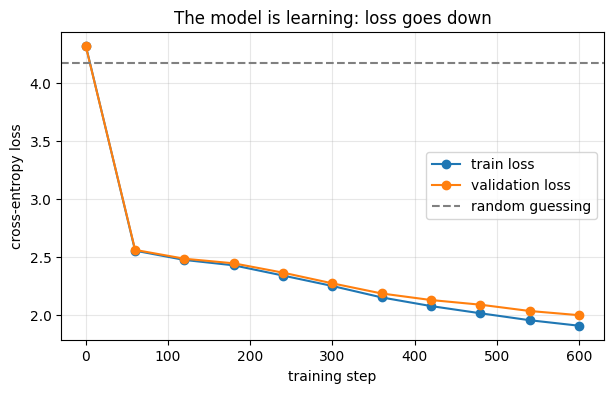

In [16]:
plt.figure(figsize=(7, 4))
plt.plot(history['step'], history['train'], 'o-', label='train loss')
plt.plot(history['step'], history['val'], 'o-', label='validation loss')
plt.axhline(math.log(vocab_size), color='gray', ls='--', label='random guessing')
plt.xlabel('training step'); plt.ylabel('cross-entropy loss')
plt.title('The model is learning: loss goes down'); plt.legend(); plt.grid(alpha=.3)
plt.show()

### 3.1 What does a trained model actually "think"? 🔍
Let's look at the model's probability distribution for the next character. This is literally everything an LLM does.

In [17]:
def show_next_token_probs(prompt, k=8):
    model.eval()
    idx = torch.tensor([encode(prompt)], device=device)
    with torch.no_grad():
        logits, _ = model(idx[:, -config['block_size']:])
    probs = F.softmax(logits[0, -1], dim=-1)
    top = torch.topk(probs, k)
    print(f"Prompt: {prompt!r}\nMost likely next characters:")
    for p, i in zip(top.values, top.indices):
        print(f"   {decode([i.item()])!r:6} {p.item()*100:5.1f}%  " + "█" * int(p.item() * 50))
    print()

show_next_token_probs("ROMEO:\nWhat light through yonder windo")
show_next_token_probs("First Citizen:\nWe are all resolved to di")
show_next_token_probs("KING HENRY:\nMy lord, I ")

Prompt: 'ROMEO:\nWhat light through yonder windo'
Most likely next characters:
   'u'     20.7%  ██████████
   ' '     18.4%  █████████
   'n'     16.6%  ████████
   'w'     14.5%  ███████
   'r'      8.8%  ████
   'm'      5.3%  ██
   'o'      3.3%  █
   's'      2.1%  █

Prompt: 'First Citizen:\nWe are all resolved to di'
Most likely next characters:
   's'     13.7%  ██████
   'e'     13.4%  ██████
   'g'     13.1%  ██████
   'n'     10.1%  █████
   'd'      9.8%  ████
   'k'      8.1%  ████
   'f'      6.6%  ███
   'v'      5.7%  ██

Prompt: 'KING HENRY:\nMy lord, I '
Most likely next characters:
   'w'     13.6%  ██████
   's'     10.4%  █████
   'h'     10.2%  █████
   'a'      9.1%  ████
   'm'      8.2%  ████
   't'      8.0%  ███
   'l'      5.4%  ██
   'n'      4.1%  ██



---
## Part 4 — Using the model: text generation

Generation is just **next-token prediction in a loop**:
```
prompt → predict probabilities → pick one token → append it → predict again → ...
```
Two knobs control *how* we pick:
- **Temperature**: low (0.5) = safe & repetitive, high (1.5) = creative & chaotic
- **Top-k**: only choose among the k most likely tokens (cuts off nonsense)

In [18]:
def generate_text(prompt, max_new_tokens=300, temperature=0.8, top_k=None, m=None):
    m = m or model
    m.eval()
    idx = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
    out = m.generate(idx, max_new_tokens, temperature=temperature, top_k=top_k)
    return decode(out[0].tolist())

print(generate_text("ROMEO:\n", max_new_tokens=400))

ROMEO:
Lord my tenothis: with mand joy herew onces: mor and the duet.

DORCKENTERDY DUKE VINELIUS:
I me ase whould sire, fol!

ELINCENIO:
Ay, the shough the meen pray,
And beads row loved comes; fork thy wath my almsens pray my smay,
And and steear, of that lesers my stan by the teye co but in the thou goods,
I sunneartans und must wome the the and lienke of I sher
And to me his the to merrore.

KING RED


In [19]:
for temp in [0.3, 0.8, 1.5]:
    print(f"========== temperature = {temp} ==========")
    print(generate_text("JULIET:\n", max_new_tokens=200, temperature=temp))
    print()

========== temperature = 0.3 ==========
JULIET:
I a so more the make him the son the to the and his so the song
And the of the son the so make beare the to the of the the the strow,
I with should the so the my so more the shat some wing me the and 

========== temperature = 0.8 ==========
JULIET:
O, now with it thou weake of the.

KING LING EDWIO:
By hop prothers sir, sight me seatto kno the monsore;
In. Grell hat in of the them menteres
Srowe, thy shat of surt, bereme of I did take.

hat of E

========== temperature = 1.5 ==========
JULIET:
Ph, treat my-seicen nof usut.

Le-toosh:
DorKEDgry, prroily,
wh:'Cle,
Digh, bufort, anuastroyefor stive, so dight;
Buster Ton mro!CPand ISencmeow thasough'd ewa$rt?

Fiourd cofc, bemmby:
Ned?
Abe ho'y



🎓 **Discussion for the class:** the model learned spelling, character names, line breaks and the *style* of a play — purely by predicting the next character. It does **not** understand meaning deeply: it is ~0.8M parameters trained for a few minutes. Scale the same recipe up ×100,000 in parameters and data, and you get modern LLMs.

**Try it:** change the prompt below and run the cell.

In [20]:
my_prompt = "To be, or not to be"   # ✏️ students: change me!
print(generate_text(my_prompt, max_new_tokens=300, temperature=0.8, top_k=20))

To be, or not to bead his and in to the firstem,
Wheath magaine time heasteris.

OSTARIOL:
God wrowath, my reeng thearrous own outh hen grest
of hich the that shall-fing weath searth one.

LEOLY, I weall thou
shant and my my fill that; to mons the put loy's and us causering the gian mude.

CLOUCESTES:
My that he so me


In [21]:
# Save the pretrained model so we can come back to it (and compare with the fine-tuned one)
import copy
torch.save({'model': model.state_dict(), 'config': config, 'chars': chars}, 'tiny_gpt_pretrained.pt')
pretrained_model = copy.deepcopy(model)  # keep an untouched copy
print("Saved to tiny_gpt_pretrained.pt ✅")

Saved to tiny_gpt_pretrained.pt ✅


---
## Part 5 — Fine-tuning

**Pre-training** (what we just did) teaches a model *language in general*.
**Fine-tuning** takes that pretrained model and **continues training it on a small, specialised dataset**, so it learns a new *task*, *format* or *style* — without starting from zero.

```
          PRE-TRAINING                              FINE-TUNING
 huge general dataset (Shakespeare)    ──►   small task dataset (Q&A pairs)
 random weights → general model              general model → specialised assistant
 expensive (days–months on real LLMs)        cheap (minutes–hours)
```

This is exactly how ChatGPT/Claude-style assistants are made: a pretrained "base model" is fine-tuned on examples of **questions and good answers** (called *instruction tuning* / *supervised fine-tuning*, SFT).

### 5.1 The fine-tuning dataset
We'll teach our Shakespeare model to answer questions in a **`Q: ... A: ...`** format. Note we must stick to characters in our vocabulary.

In [22]:
qa_pairs = [
    ("What is a token?", "A token is a small piece of text, like a word or a character."),
    ("What is an LLM?", "An LLM is a large language model that predicts the next token."),
    ("What is attention?", "Attention lets each token look at the tokens before it."),
    ("What is training?", "Training adjusts the weights to make the loss smaller."),
    ("What is fine-tuning?", "Fine-tuning trains a pretrained model on a small special dataset."),
    ("What is an embedding?", "An embedding is a vector of numbers that represents a token."),
    ("What is the loss?", "The loss measures how wrong the predictions of the model are."),
    ("What is a transformer?", "A transformer is a stack of attention and feed-forward blocks."),
    ("Who wrote Hamlet?", "Hamlet was written by William Shakespeare."),
    ("What is temperature?", "Temperature controls how random the generated text is."),
]

def format_example(q, a):
    return f"Q: {q}\nA: {a}\n\n"

ft_text = "".join(format_example(q, a) for q, a in qa_pairs)
# keep only characters the model knows (our tokenizer can't encode new characters)
assert all(c in stoi for c in ft_text), "Fine-tuning text contains characters not in the vocabulary!"
print(ft_text[:300])
print(f"Fine-tuning dataset: {len(qa_pairs)} examples, {len(ft_text)} characters "
      f"(vs {len(text):,} for pretraining)")

Q: What is a token?
A: A token is a small piece of text, like a word or a character.

Q: What is an LLM?
A: An LLM is a large language model that predicts the next token.

Q: What is attention?
A: Attention lets each token look at the tokens before it.

Q: What is training?
A: Training adjusts the w
Fine-tuning dataset: 10 examples, 849 characters (vs 1,115,394 for pretraining)


### 5.2 Before fine-tuning: ask the pretrained model a question
It only knows Shakespeare — it has never seen the Q&A format.

In [23]:
def ask(m, question, max_new_tokens=80):
    torch.manual_seed(1)
    prompt = f"Q: {question}\nA:"
    out = generate_text(prompt, max_new_tokens=max_new_tokens, temperature=0.2, m=m)
    answer = out[len(prompt):].split("\n\n")[0]    # stop at the blank line that ends an example
    return answer.strip().replace("\n", " / ")

for q in ["What is a token?", "What is attention?"]:
    print(f"Q: {q}\nA (pretrained model): {ask(pretrained_model, q)}\n")

Q: What is a token?
A (pretrained model): I whould shall and the the me of the shall the some and and the some the his of

Q: What is attention?
A (pretrained model): I what her the may the the me of the shat the sould and the the sone / The his of



### 5.3 Full fine-tuning
Same training loop as before, but with three important differences:
1. **Start from the pretrained weights** (not random)
2. **Small dataset** — our Q&A text
3. **Smaller learning rate** — gentle updates so we don't destroy what the model already knows ("catastrophic forgetting")

In [24]:
ft_data = torch.tensor(encode(ft_text), dtype=torch.long)
ft_block = 64   # our examples are short, so a shorter context is enough

def get_ft_batch(batch_size=16, block_size=ft_block):
    d = torch.cat([ft_data, ft_data])  # wrap around so we can sample anywhere
    ix = torch.randint(len(ft_data), (batch_size,))
    x = torch.stack([d[i:i + block_size] for i in ix])
    y = torch.stack([d[i + 1:i + block_size + 1] for i in ix])
    return x.to(device), y.to(device)

ft_model = copy.deepcopy(pretrained_model)                              # 1. start from pretrained
ft_optimizer = torch.optim.AdamW(ft_model.parameters(), lr=3e-4)        # 3. smaller learning rate
ft_model.train()

for step in range(801):
    xb, yb = get_ft_batch()                                             # 2. the small Q&A dataset
    _, loss = ft_model(xb, yb)
    ft_optimizer.zero_grad(set_to_none=True)
    loss.backward()
    ft_optimizer.step()
    if step % 200 == 0:
        print(f"fine-tune step {step:4d} | loss {loss.item():.3f}")
print("Full fine-tuning done ✅")

fine-tune step    0 | loss 2.703
fine-tune step  200 | loss 0.396
fine-tune step  400 | loss 0.188
fine-tune step  600 | loss 0.125
fine-tune step  800 | loss 0.102
Full fine-tuning done ✅


In [25]:
print("=" * 60)
for q in ["What is a token?", "What is attention?", "What is fine-tuning?", "Who wrote Hamlet?"]:
    print(f"Q: {q}")
    print(f"   BEFORE fine-tuning: {ask(pretrained_model, q)}")
    print(f"   AFTER  fine-tuning: {ask(ft_model, q)}")
    print()

Q: What is a token?
   BEFORE fine-tuning: I whould shall and the the me of the shall the some and and the some the his of
   AFTER  fine-tuning: A token is a small piece of text, like a wor a word a ward or a characten ten a

Q: What is attention?
   BEFORE fine-tuning: I what her the may the the me of the shat the sould and the the sone / The his of
   AFTER  fine-tuning: Attention lets each token look at the tokens tokens s smal speactens eatatactio

Q: What is fine-tuning?
   BEFORE fine-tuning: I word here the and so the me of the sore of the the the son the my the my so t
   AFTER  fine-tuning: Fine-tuning trains a pretrained model on a smal a s smal special dataset.

Q: Who wrote Hamlet?
   BEFORE fine-tuning: I well heare so and so the me of the me make the me and the the son / I him son t
   AFTER  fine-tuning: Hamlet was written by William Shakespeare.



🎓 **What happened?** The model learned the **format** (`Q:` → `A:` → answer → stop) and the **content** of our examples. With only 10 examples it mostly *memorises* them — real fine-tuning uses thousands to millions of examples so the model *generalises* to new questions.

### 5.4 Parameter-efficient fine-tuning: **LoRA** (how it's done in industry)
Full fine-tuning updates **all** weights. For a 70-billion-parameter model that needs huge GPU memory. **LoRA (Low-Rank Adaptation)** instead:
- **freezes** all original weights 🧊
- adds tiny trainable "adapter" matrices `A` and `B` next to some layers
- new weight = `W_frozen + B·A` where `B·A` is low-rank (rank `r` = 4, 8, 16...)

```
 x ──►[ W  (frozen, big) ]──────────┐
 │                                  (+)──► output
 └──►[ A (r×in) ]──►[ B (out×r) ]───┘     only A and B are trained!
```
Let's implement it ourselves in ~15 lines:

In [26]:
class LoRALinear(nn.Module):
    # Wraps an existing nn.Linear: output = W x + (B A x) * scale, with W frozen
    def __init__(self, base: nn.Linear, r=4, alpha=8):
        super().__init__()
        self.base = base
        for p in self.base.parameters():
            p.requires_grad = False                                   # freeze original weight
        self.A = nn.Parameter(torch.randn(r, base.in_features) * 0.01)
        self.B = nn.Parameter(torch.zeros(base.out_features, r))      # zero-init: starts as "no change"
        self.scale = alpha / r

    def forward(self, x):
        return self.base(x) + (x @ self.A.T @ self.B.T) * self.scale


def add_lora(m, r=4):
    # 1) freeze EVERYTHING
    for p in m.parameters():
        p.requires_grad = False
    # 2) add small LoRA adapters next to the attention (q, k, v) and feed-forward layers
    for block in m.blocks:
        for head in block.attn.heads:
            head.query = LoRALinear(head.query, r=r)
            head.key   = LoRALinear(head.key, r=r)
            head.value = LoRALinear(head.value, r=r)
        block.ffwd.net[0] = LoRALinear(block.ffwd.net[0], r=r)
        block.ffwd.net[2] = LoRALinear(block.ffwd.net[2], r=r)
    return m

lora_model = add_lora(copy.deepcopy(pretrained_model)).to(device)

trainable = sum(p.numel() for p in lora_model.parameters() if p.requires_grad)
total = sum(p.numel() for p in lora_model.parameters())
print(f"Trainable parameters: {trainable:,} out of {total:,}  ->  only {100*trainable/total:.1f}% !")

Trainable parameters: 51,200 out of 876,097  ->  only 5.8% !


In [27]:
lora_optimizer = torch.optim.AdamW([p for p in lora_model.parameters() if p.requires_grad], lr=5e-3)
lora_model.train()
for step in range(1201):
    xb, yb = get_ft_batch()
    _, loss = lora_model(xb, yb)
    lora_optimizer.zero_grad(set_to_none=True)
    loss.backward()
    lora_optimizer.step()
    if step % 300 == 0:
        print(f"LoRA step {step:4d} | loss {loss.item():.3f}")

print()
for q in ["What is a token?", "What is the loss?", "Who wrote Hamlet?"]:
    print(f"Q: {q}\n   LoRA model: {ask(lora_model, q)}\n")

LoRA step    0 | loss 2.475
LoRA step  300 | loss 0.459
LoRA step  600 | loss 0.315
LoRA step  900 | loss 0.272
LoRA step 1200 | loss 0.282

Q: What is a token?
   LoRA model: A token is a small piece of text, like a word a word a word oractention a a an

Q: What is the loss?
   LoRA model: The loss measures how wrong the predictions onerats the cons thel nere rains a

Q: Who wrote Hamlet?
   LoRA model: Hamlet was written by William Shakespeare.



### 5.5 Did fine-tuning make the model forget Shakespeare? (catastrophic forgetting)

In [28]:
for name, m in [("Pretrained", pretrained_model), ("Full fine-tune", ft_model), ("LoRA fine-tune", lora_model)]:
    torch.manual_seed(7)
    print(f"----- {name} -----")
    print(generate_text("ROMEO:\n", max_new_tokens=150, temperature=0.8, m=m))
    print()

----- Pretrained -----
ROMEO:
At 'Tand of swill, know!

QUEESTESSS:
How him be my thymer:
I me bord so weer, at him a chered be megand in en'd
I ming have king the store wearterge 

----- Full fine-tune -----
ROMEO:
A: A transformer is a stack of attention and feed-forward blocks.

Q: Whow Hamlet trat reprepe is text is a tokentratungentraing?
A: A token loodel lo

----- LoRA fine-tune -----
ROMEO:
A: An embedding is a vector of numbers that represents a tokentrens atUkenter, len is a che ol thenext talere locks: bere is a tokens a prenel a coge 



### 5.6 Fine-tuning recipe — for your future projects 🗺️

| Step | What to do | Tips |
|---|---|---|
| 1. Pick a base model | A pretrained model close to your needs | Start small: SmolLM2-135M/360M, Qwen2.5-0.5B, Llama-3.2-1B |
| 2. Prepare data | Hundreds–thousands of high-quality **input → desired output** examples | Quality ≫ quantity. Use the model's **chat template** format |
| 3. Choose method | **Full** fine-tuning (small models) or **LoRA / QLoRA** (big models, small GPU) | QLoRA = LoRA + 4-bit weights → fine-tune a 7B model on a free Colab T4 |
| 4. Train | Low learning rate (1e-5 full / 1e-4–3e-4 LoRA), 1–3 epochs | Watch validation loss — stop when it starts rising (overfitting) |
| 5. Evaluate | Test on examples the model **never saw** | Also check it didn't forget general skills |
| 6. Deploy | Merge LoRA weights into the base model, or load adapters on top | |

**Tools used in practice:** Hugging Face `transformers` + `peft` (LoRA) + `trl` (`SFTTrainer`), or Unsloth / Axolotl for speed.

Beyond supervised fine-tuning, assistants are further aligned with **RLHF / DPO** (learning from human preferences between two answers).

---
## Part 6 (Bonus) — Use and fine-tune a *real* small pretrained LLM
Everything we built by hand exists ready-made in the Hugging Face library. Here we use **SmolLM2-135M** — one of the smallest modern LLMs (135 million parameters, ~170× bigger than ours, pretrained on trillions of tokens).

> Requires internet access to download the model (~270 MB). Takes 1–2 minutes on a T4 GPU.

In [29]:
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "HuggingFaceTB/SmolLM2-135M"
hf_tok = AutoTokenizer.from_pretrained(model_name)
hf_model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
if hf_tok.pad_token is None:
    hf_tok.pad_token = hf_tok.eos_token

print(f"Parameters: {sum(p.numel() for p in hf_model.parameters())/1e6:.0f} M")
print(f"Vocabulary: {hf_tok.vocab_size:,} sub-word tokens (ours: {vocab_size} characters)")
print(hf_model)   # 👀 same building blocks: embeddings, attention (q/k/v), MLP, norms, lm_head!

config.json:   0%|          | 0.00/704 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.66k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/801k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/831 [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  269MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

Parameters: 135 M
Vocabulary: 49,152 sub-word tokens (ours: 65 characters)
LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(49152, 576)
    (layers): ModuleList(
      (0-29): 30 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=576, out_features=576, bias=False)
          (k_proj): Linear(in_features=576, out_features=192, bias=False)
          (v_proj): Linear(in_features=576, out_features=192, bias=False)
          (o_proj): Linear(in_features=576, out_features=576, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=576, out_features=1536, bias=False)
          (up_proj): Linear(in_features=576, out_features=1536, bias=False)
          (down_proj): Linear(in_features=1536, out_features=576, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((576,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((576,), eps=1e-05)
    

In [30]:
def hf_generate(prompt, max_new_tokens=40):
    hf_model.eval()
    inputs = hf_tok(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        out = hf_model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False,
                                pad_token_id=hf_tok.eos_token_id)
    return hf_tok.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)

print("Same tokenization idea, real BPE tokens:", hf_tok.tokenize("Fine-tuning language models"))
print()
print("BEFORE fine-tuning:")
print("Q: What is our class about?\nA:" + hf_generate("Q: What is our class about?\nA:"))

Same tokenization idea, real BPE tokens: ['Fine', '-', 'tuning', 'Ġlanguage', 'Ġmodels']

BEFORE fine-tuning:
Q: What is our class about?
A: We are a group of students who are interested in the history of the United States. We are interested in the history of the United States, and we are interested in the history of the United States,


In [31]:
# Fine-tune the real model on a few examples — the SAME loop we wrote for TinyGPT!
hf_examples = [
    "Q: What is our class about?\nA: Our class is about building a tiny LLM from scratch.",
    "Q: Who is the best teacher?\nA: Our teacher, of course!",
    "Q: What did we build today?\nA: We built TinyGPT, a small transformer language model.",
] * 4

hf_opt = torch.optim.AdamW(hf_model.parameters(), lr=1e-4)
hf_model.train()
for epoch in range(8):   # a few more passes so it really learns our answers
    total = 0
    for ex in hf_examples:
        batch = hf_tok(ex + hf_tok.eos_token, return_tensors="pt").to(device)
        out = hf_model(**batch, labels=batch["input_ids"])   # HF shifts labels by 1 internally
        hf_opt.zero_grad(); out.loss.backward(); hf_opt.step()
        total += out.loss.item()
    print(f"epoch {epoch+1} | avg loss {total/len(hf_examples):.3f}")

print("\nAFTER fine-tuning:")
print("Q: What is our class about?\nA:" + hf_generate("Q: What is our class about?\nA:"))

epoch 1 | avg loss 2.350
epoch 2 | avg loss 0.810
epoch 3 | avg loss 0.253
epoch 4 | avg loss 0.125
epoch 5 | avg loss 0.088
epoch 6 | avg loss 0.075
epoch 7 | avg loss 0.072
epoch 8 | avg loss 0.069

AFTER fine-tuning:
Q: What is our class about?
A: Our class is about building a tiny LLM from scratch.


---
## 🎉 Recap — what we learned

| Concept | What we saw in code |
|---|---|
| **Data processing** | text → characters → IDs → (input, shifted target) batches |
| **Architecture** | token + position embeddings → N × [attention + feed-forward] → logits |
| **Self-attention** | Query · Key scores → causal mask → softmax → weighted sum of Values |
| **Training** | forward → cross-entropy loss → backward → AdamW step, repeated |
| **Using the model** | predict → sample (temperature, top-k) → append → repeat |
| **Fine-tuning** | continue training a pretrained model on a small task dataset; LoRA trains <5% of weights |

### 🧪 Exercises for students
1. Make the model bigger (`n_layer=6`, `n_embd=192`) — does the validation loss improve? How long does training take?
2. Train on your **own text** (song lyrics you wrote, a book in your language, your notes) — replace `text = ...` in Part 1.
3. Add 10 of your own Q&A pairs to the fine-tuning dataset.
4. Change LoRA rank `r` from 4 to 1 or 16 — what changes?

### 📚 Going further
- Andrej Karpathy — *"Let's build GPT: from scratch, in code, spelled out"* (YouTube) — this notebook follows the same spirit
- *Attention Is All You Need* (Vaswani et al., 2017) — the original Transformer paper
- Hugging Face LLM Course — huggingface.co/learn